# Step 3 — Compute Ground Truth Spread
Aggregate the observed spread from orderbook ask0/bid0 into 1-second bars

In [3]:
import pandas as pd
import numpy as np
import glob, re

SYMBOLS   = ['WIFUSDT', 'ZAMAUSDT']
DATA_DIR  = '../data'
OUT_DIR   = '../results'
files = glob.glob(f'{DATA_DIR}/{SYMBOLS[0]}_orderbook_*.parquet')
DATES = sorted(re.search(r'(\d{4}-\d{2}-\d{2})', f).group(1) for f in files)
print(f'Detected dates: {DATES}')


Detected dates: ['2026-04-12', '2026-04-13', '2026-04-14']


## 1. Compute observed spread and aggregate into 1-second bars

In [4]:
def compute_ground_truth_spread(symbol: str) -> pd.DataFrame:
    frames = []
    for date in DATES:
        df = pd.read_parquet(f'{DATA_DIR}/{symbol}_orderbook_{date}.parquet')

        # use only the best ask / bid
        df['mid']              = (df['ask0'] + df['bid0']) / 2
        df['abs_spread']       = df['ask0'] - df['bid0']
        df['relative_spread']  = df['abs_spread'] / df['mid']

        frames.append(df[['mid', 'abs_spread', 'relative_spread']])

    ob = pd.concat(frames).sort_index()

    # convert the index to tz-naive UTC seconds for resampling
    ob.index = ob.index.tz_convert('UTC').tz_localize(None)

    # 1-second bars: use the last observation in each second
    ob_1s = ob.resample('1s').last().dropna()

    return ob_1s

gt = {}
for symbol in SYMBOLS:
    gt[symbol] = compute_ground_truth_spread(symbol)
    print(f'{symbol}: {len(gt[symbol])} seconds of data')
    print(gt[symbol].head(3))
    print()

WIFUSDT: 175452 seconds of data
                        mid  abs_spread  relative_spread
2026-04-11 22:00:00  0.2005       0.001         0.004988
2026-04-11 22:00:01  0.2005       0.001         0.004988
2026-04-11 22:00:02  0.2005       0.001         0.004988

ZAMAUSDT: 156973 seconds of data
                          mid  abs_spread  relative_spread
2026-04-11 22:00:00  0.026095     0.00001         0.000383
2026-04-11 22:00:02  0.026105     0.00003         0.001149
2026-04-11 22:00:03  0.026095     0.00001         0.000383



## 2. Check basic statistics

In [5]:
for symbol in SYMBOLS:
    print(f'=== {symbol} ===')
    print(gt[symbol]['relative_spread'].describe())
    print()

=== WIFUSDT ===
count    175452.000000
mean          0.005206
std           0.000114
min           0.004914
25%           0.005115
50%           0.005249
75%           0.005305
max           0.005391
Name: relative_spread, dtype: float64

=== ZAMAUSDT ===
count    156973.000000
mean          0.000443
std           0.000193
min           0.000239
25%           0.000373
50%           0.000391
75%           0.000402
max           0.011246
Name: relative_spread, dtype: float64



## 3. Visualization (spread time series)

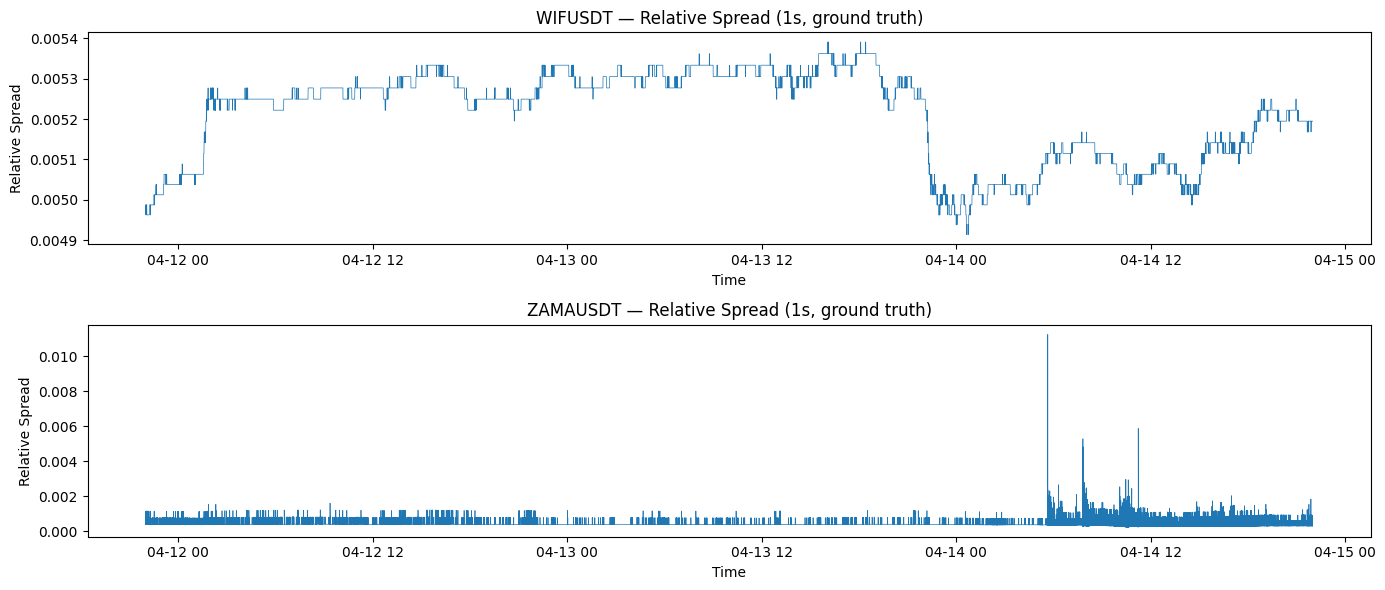

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, symbol in zip(axes, SYMBOLS):
    ax.plot(gt[symbol].index, gt[symbol]['relative_spread'], lw=0.5)
    ax.set_title(f'{symbol} — Relative Spread (1s, ground truth)')
    ax.set_ylabel('Relative Spread')
    ax.set_xlabel('Time')

plt.tight_layout()
plt.show()

## 4. Save results (for use by B)

In [9]:
import os
os.makedirs(OUT_DIR, exist_ok=True)

for symbol in SYMBOLS:
    out_path = f'{OUT_DIR}/{symbol}_ground_truth_spread_1s.parquet'
    gt[symbol].to_parquet(out_path)
    print(f'Saved: {out_path}')

Saved: ../results/WIFUSDT_ground_truth_spread_1s.parquet
Saved: ../results/ZAMAUSDT_ground_truth_spread_1s.parquet
